# Kinematic Data Evaluation

Use this notebook to inspect individual kinematic trials and evaluate segment-length stability.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "KinematicPlot.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repository root: {ROOT}")

Repository root: C:\Users\agrawal-admin\Desktop\AnalysisAndFigures


In [2]:
import KinematicPlot as kp
from group_config_new import build_groups

FIGURES_DIR = ROOT / "Figures" / "Evaluation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plotter = kp.PlotCreator(
    platform_offset=0.07,
    platform_height=0.1,
    radius=0.03,
    fps=250,
)

groups = build_groups()
print(f"Loaded {len(groups)} groups")

Loaded 48 groups


## Inputs

Edit these values before running the plot cells.

In [3]:
GROUP_NAME = "WT_T2_TTa"
FLY_NUMBER = 1
TRIAL_NUMBER = 1
FRAME_NUMBER = 200
EVAL_START_FRAME = 0
EVAL_STOP_FRAME = None  # use None for the end of the trial

PLANE_AXIS = ("R-mBC", "L-mBC")
ORIGIN_KEYPOINT = "R-mBC"

SEGMENTS = [
    ["L-mBC", "L-mCT"],
    ["L-mCT", "L-mFT"],
    ["L-mFT", "L-mTT"],
]

## Single-Frame 2D Projection

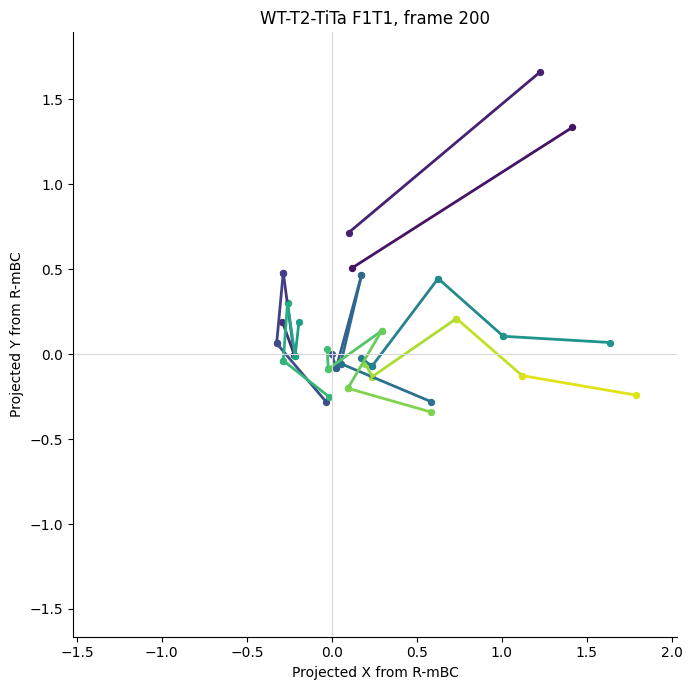

In [4]:
fig, ax, trial_info = plotter.show_kinematic_frame_projected_2d(
    groups=groups,
    group_name=GROUP_NAME,
    fly_number=FLY_NUMBER,
    trial_number=TRIAL_NUMBER,
    frame_number=FRAME_NUMBER,
    plane_axis=PLANE_AXIS,
    origin_keypoint=ORIGIN_KEYPOINT,
    segments=None,
    show_labels=False,
)

## Segment-Length Change

,Group_Name,Fly#,Trial#,Frame,Time_s,Segment,Point_A,Point_B,Length_3D,Baseline_Length_3D,Delta_Length_3D,Percent_Change_From_Baseline,Baseline_Frames,Baseline_Seconds,Plot_Start_Frame,Plot_Stop_Frame
0,WT-T2-TiTa,1,1,0,0.000,L-mBC-L-mCT,L-mBC,L-mCT,0.142811,0.133862,0.008949,6.685215,200,1.0,0,1399
1,WT-T2-TiTa,1,1,1,0.005,L-mBC-L-mCT,L-mBC,L-mCT,0.140888,0.133862,0.007026,5.248510,200,1.0,0,1399
2,WT-T2-TiTa,1,1,2,0.010,L-mBC-L-mCT,L-mBC,L-mCT,0.134903,0.133862,0.001041,0.777836,200,1.0,0,1399
3,WT-T2-TiTa,1,1,3,0.015,L-mBC-L-mCT,L-mBC,L-mCT,0.130818,0.133862,-0.003044,-2.274015,200,1.0,0,1399
4,WT-T2-TiTa,1,1,4,0.020,L-mBC-L-mCT,L-mBC,L-mCT,0.130756,0.133862,-0.003106,-2.320668,200,1.0,0,1399


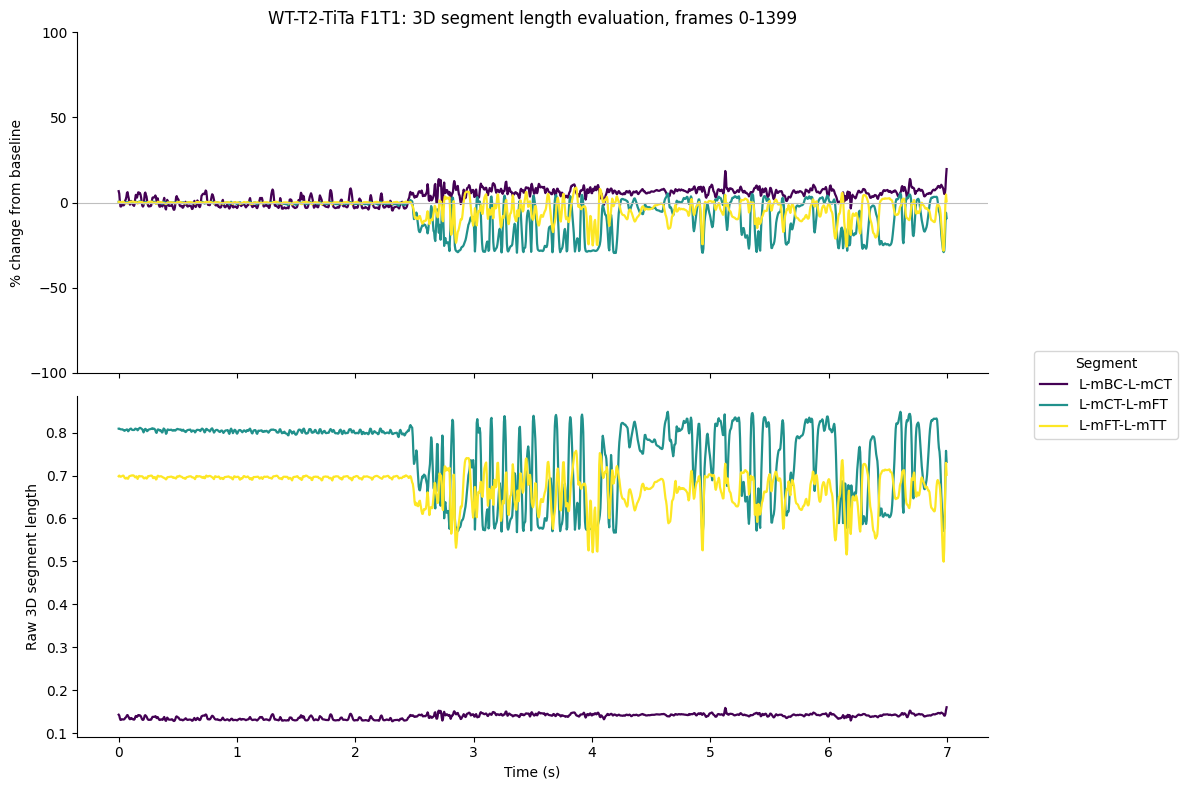

In [5]:
output_prefix = FIGURES_DIR / f"{GROUP_NAME}_F{FLY_NUMBER}T{TRIAL_NUMBER}_segment_length_change"

result = plotter.plot_segment_length_change_evaluation(
    groups=groups,
    group_name=GROUP_NAME,
    fly_number=FLY_NUMBER,
    trial_number=TRIAL_NUMBER,
    segments=SEGMENTS,
    baseline_seconds=1.0,
    start_frame=EVAL_START_FRAME,
    stop_frame=EVAL_STOP_FRAME,
    file_name=str(output_prefix),
    save_csv=True,
)

# Current function returns (fig, axes, length_df). If the notebook kernel still
# has the older function loaded, it may return extra raw-figure objects.
fig, axes, length_df = result[0], result[1], result[-1]

length_df.head()

## Single-Frame 3D View

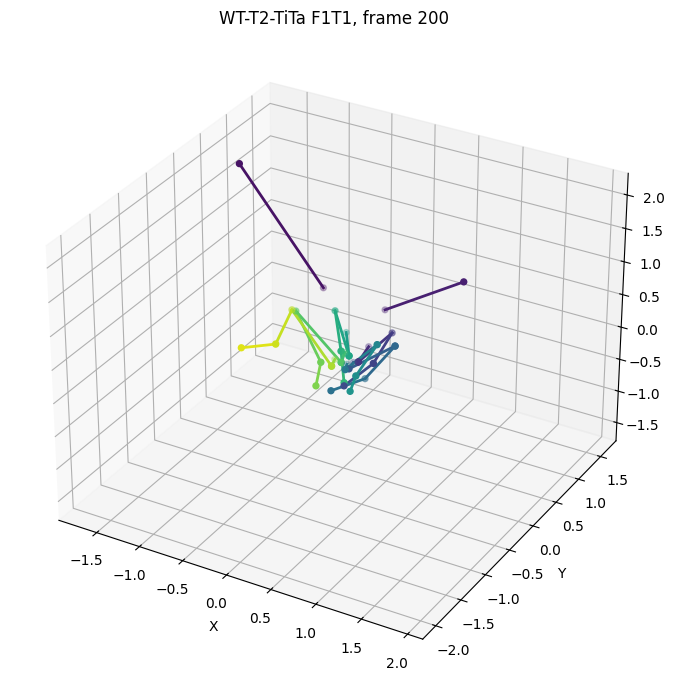

In [6]:
fig, ax, trial_info = plotter.show_kinematic_frame_3d(
    groups=groups,
    group_name=GROUP_NAME,
    fly_number=FLY_NUMBER,
    trial_number=TRIAL_NUMBER,
    frame_number=FRAME_NUMBER,
    segments=None,
    show_labels=False,
)

## MOC-Aligned Average Segment-Length ChangeThis summarizes all loaded trials for one group. Baseline normalization is still computed per trial from the first second; traces are aligned to MOC and resampled before averaging.

,Segment,Point_A,Point_B,Time_From_MOC_s,Mean_Percent_Change,Std_Percent_Change,Mean_Delta_Length_3D,Std_Delta_Length_3D,n_trials
0,L-mBC-L-mCT,L-mBC,L-mCT,-0.200,0.053062,0.945381,0.000056,0.001120,195
1,L-mBC-L-mCT,L-mBC,L-mCT,-0.196,0.056677,0.915434,0.000059,0.001085,195
2,L-mBC-L-mCT,L-mBC,L-mCT,-0.192,0.044078,0.913952,0.000044,0.001082,195
3,L-mBC-L-mCT,L-mBC,L-mCT,-0.188,0.004343,0.930442,-0.000002,0.001099,195
4,L-mBC-L-mCT,L-mBC,L-mCT,-0.184,-0.053795,0.937432,-0.000071,0.001105,195


""


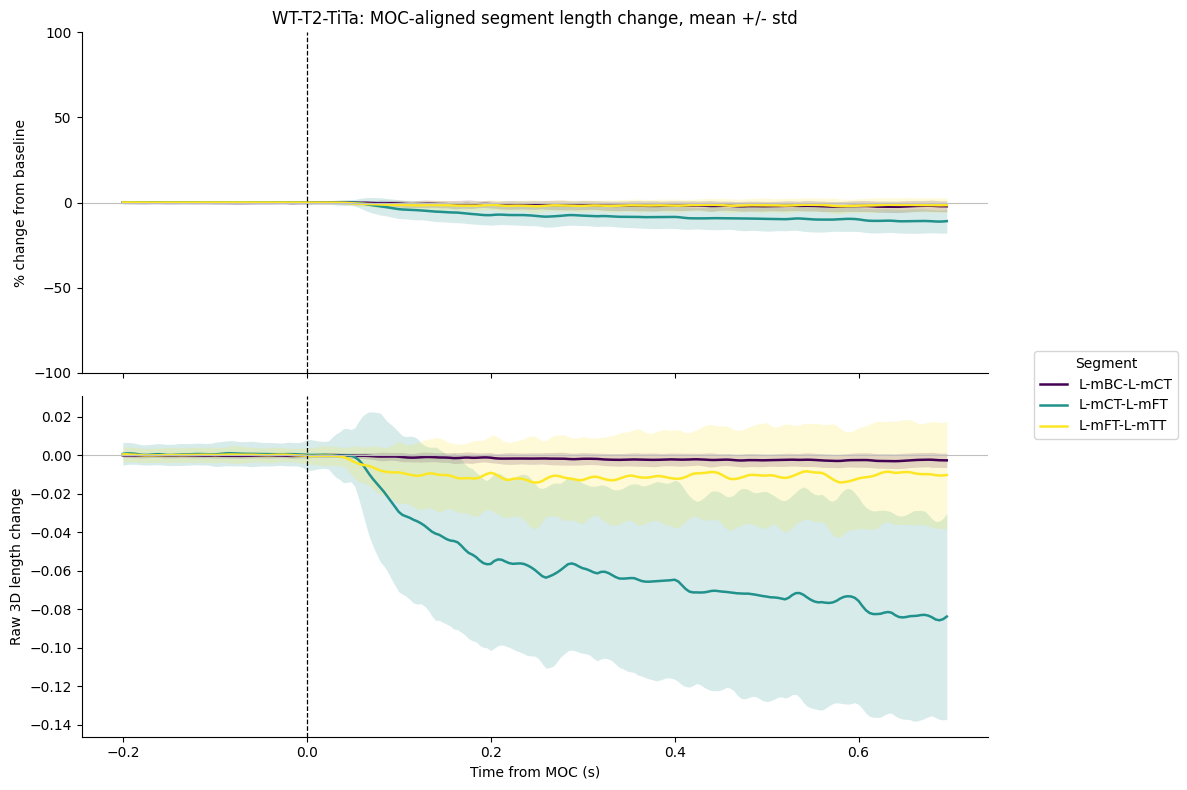

In [7]:
AVG_START_S = -0.2
AVG_STOP_S = 0.7
AVG_TARGET_FPS = 250
avg_output_prefix = FIGURES_DIR / f"{GROUP_NAME}_MOC_aligned_segment_length_change_average"
avg_fig, avg_axes, trial_trace_df, summary_df, skipped_df = plotter.plot_segment_length_change_average_moc_aligned(    
    groups=groups,    
    group_name=GROUP_NAME,    
    segments=SEGMENTS,    
    start_s=AVG_START_S,    
    stop_s=AVG_STOP_S,    
    target_fps=AVG_TARGET_FPS,    
    trial_types=("Landing", "Flying"),    
    baseline_seconds=1.0,    
    file_name=str(avg_output_prefix),    
    save_csv=True,)

display(summary_df.head())
display(skipped_df.head())

## Tracking Quality QC

These plots use MOC->MOL for successful trials and MOC->tau for failed/flying trials. The diagnostic tracking window extends the analysis window by 0.2 s on each side.

In [8]:
QC_KEYPOINTS = [
    "L-fBC", "L-mBC", "L-hBC",
    "L-fCT", "L-mCT", "L-hCT",
    "L-fFT", "L-mFT", "L-hFT",
    "L-fTT", "L-mTT", "L-hTT",
    "R-fBC", "R-mBC", "R-hBC",
    "R-fCT", "R-mCT", "R-hCT",
    "R-fFT", "R-mFT", "R-hFT",
    "R-fTT", "R-mTT", "R-hTT",
    "platform-tip",
]

QC_TAU = 0.71
QC_MARGIN_S = 0.2
QC_MIN_CAMERAS = 2
QC_MAX_ERROR = None  # set to a numeric threshold after inspecting error distributions
SINGLE_TRIAL_QC_KEYPOINT = "L-mTT"

qc_out = FIGURES_DIR / f"{GROUP_NAME}_tracking_quality"
qc_out.mkdir(parents=True, exist_ok=True)

qc_kwargs = dict(
    tau=QC_TAU,
    margin_s=QC_MARGIN_S,
    min_cameras=QC_MIN_CAMERAS,
    max_error=QC_MAX_ERROR,
)

### 1. Error Distribution By Keypoint

,Keypoint,Percentile_Error
0,L-fBC,8.105387
8,L-mBC,7.465678
4,L-hBC,8.276787
1,L-fCT,7.574249
9,L-mCT,7.716709


,Group_Name,Index,Fly#,Trial#,TrialType,Outcome,Keypoint,Frame,Time_From_MOC_s,In_Analysis_Window,...,Error,Finite_Coordinates,Finite_Error,Camera_OK,Error_OK,Valid_QC_Frame,Min_Cameras,Max_Error,Tau_s,Margin_s
0,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,267,-0.200,False,...,0.784245,True,True,True,True,True,2,None,0.71,0.2
1,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,268,-0.195,False,...,1.022917,True,True,True,True,True,2,None,0.71,0.2
2,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,269,-0.190,False,...,0.431294,True,True,True,True,True,2,None,0.71,0.2
3,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,270,-0.185,False,...,1.598918,True,True,True,True,True,2,None,0.71,0.2
4,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,271,-0.180,False,...,2.448455,True,True,True,True,True,2,None,0.71,0.2


""


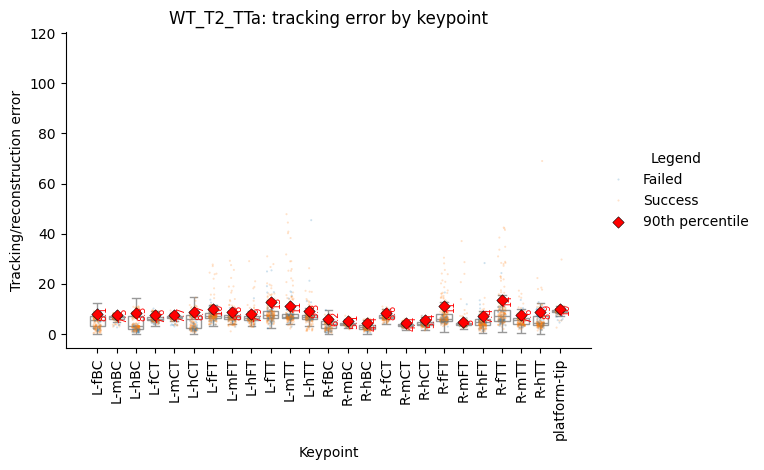

In [9]:
fig, ax, error_percentile_df, error_qc_df, error_skipped_df = plotter.plot_tracking_error_distribution(
    groups=groups,
    group_name=GROUP_NAME,
    keypoints=QC_KEYPOINTS,
    percentile=90,
    file_name=str(qc_out / "01_error_distribution_by_keypoint"),
    **qc_kwargs,
)

display(error_percentile_df.head())
display(error_qc_df.head())
display(error_skipped_df.head())

### 2. Camera Count Distribution By Keypoint

,Keypoint,Camera_Count,Frame_Count,Frame_Fraction
0,L-fBC,1.0,77,0.005342
1,L-fBC,2.0,4541,0.315041
2,L-fBC,3.0,4939,0.342653
3,L-fBC,4.0,4823,0.334605
4,L-fBC,5.0,34,0.002359


""


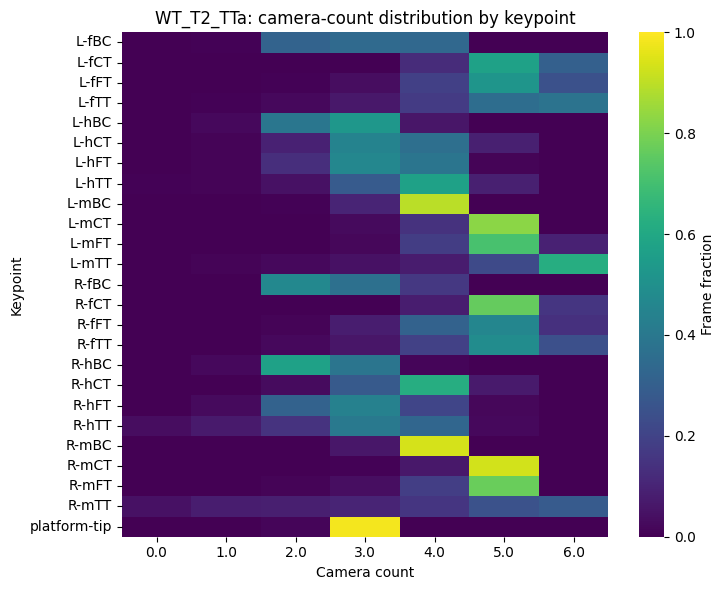

In [10]:
fig, ax, camera_count_df, camera_qc_df, camera_skipped_df = plotter.plot_tracking_camera_count_distribution(
    groups=groups,
    group_name=GROUP_NAME,
    keypoints=QC_KEYPOINTS,
    file_name=str(qc_out / "02_camera_count_distribution_by_keypoint"),
    **qc_kwargs,
)

display(camera_count_df.head())
display(camera_skipped_df.head())

### 3. Error By Camera Count

,Group_Name,Index,Fly#,Trial#,TrialType,Outcome,Keypoint,Frame,Time_From_MOC_s,In_Analysis_Window,...,Error,Finite_Coordinates,Finite_Error,Camera_OK,Error_OK,Valid_QC_Frame,Min_Cameras,Max_Error,Tau_s,Margin_s
0,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,267,-0.200,False,...,0.784245,True,True,True,True,True,2,None,0.71,0.2
1,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,268,-0.195,False,...,1.022917,True,True,True,True,True,2,None,0.71,0.2
2,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,269,-0.190,False,...,0.431294,True,True,True,True,True,2,None,0.71,0.2
3,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,270,-0.185,False,...,1.598918,True,True,True,True,True,2,None,0.71,0.2
4,WT-T2-TiTa,"(1, 4)",1,4,Landing,Success,L-fBC,271,-0.180,False,...,2.448455,True,True,True,True,True,2,None,0.71,0.2


""


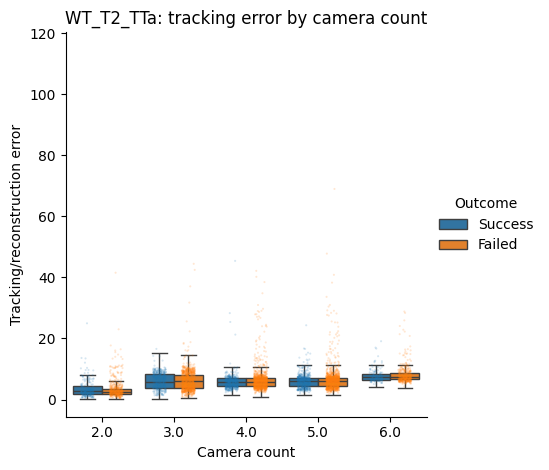

In [11]:
fig, ax, error_by_camera_qc_df, error_by_camera_skipped_df = plotter.plot_tracking_error_by_camera_count(
    groups=groups,
    group_name=GROUP_NAME,
    keypoints=QC_KEYPOINTS,
    file_name=str(qc_out / "03_error_by_camera_count"),
    **qc_kwargs,
)

display(error_by_camera_qc_df.head())
display(error_by_camera_skipped_df.head())

### 4. Valid Frame Fraction In Analysis Window

,Index,Fly#,Trial#,Outcome,Keypoint,Valid_Frame_Fraction,n_frames,Median_Error,Min_Camera_Count
0,"(1, 10)",1,10,Success,L-fBC,1.0,23,6.826798,2.0
1,"(1, 10)",1,10,Success,L-fCT,1.0,23,5.951451,5.0
2,"(1, 10)",1,10,Success,L-fFT,1.0,23,7.169963,4.0
3,"(1, 10)",1,10,Success,L-fTT,1.0,23,7.949820,2.0
4,"(1, 10)",1,10,Success,L-hBC,1.0,23,3.157393,2.0


""


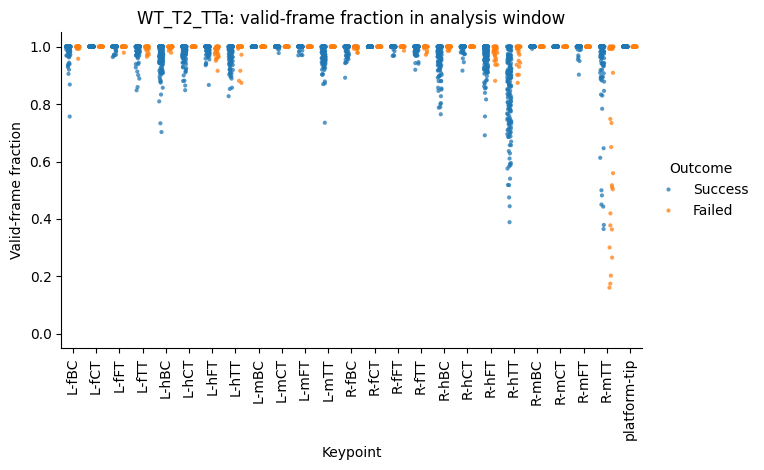

In [12]:
fig, ax, valid_fraction_df, valid_qc_df, valid_skipped_df = plotter.plot_tracking_valid_frame_fraction(
    groups=groups,
    group_name=GROUP_NAME,
    keypoints=QC_KEYPOINTS,
    file_name=str(qc_out / "04_valid_frame_fraction"),
    **qc_kwargs,
)

display(valid_fraction_df.head())
display(valid_skipped_df.head())

### Single-Trial Error And Camera Count Over Time

This plots tracking error and camera count for one fly/trial, aligned to MOC. The shaded region is the analysis window.

,Group_Name,Index,CSV_Path,Fly#,Trial#,TrialType,Outcome,Keypoint,Frame,Frame_0based,...,Error,Finite_Coordinates,Finite_Error,Camera_OK,Error_OK,Valid_QC_Frame,Min_Cameras,Max_Error,Tau_s,Margin_s
0,WT-T2-TiTa,"(1, 1)",D:\TibiaTarsusPlatformODLight-Wayne-2024-10-19...,1,1,Landing,Success,L-mTT,443,443,...,5.937212,True,True,True,True,True,2,None,0.71,0.2
1,WT-T2-TiTa,"(1, 1)",D:\TibiaTarsusPlatformODLight-Wayne-2024-10-19...,1,1,Landing,Success,L-mTT,444,444,...,5.636033,True,True,True,True,True,2,None,0.71,0.2
2,WT-T2-TiTa,"(1, 1)",D:\TibiaTarsusPlatformODLight-Wayne-2024-10-19...,1,1,Landing,Success,L-mTT,445,445,...,4.309726,True,True,True,True,True,2,None,0.71,0.2
3,WT-T2-TiTa,"(1, 1)",D:\TibiaTarsusPlatformODLight-Wayne-2024-10-19...,1,1,Landing,Success,L-mTT,446,446,...,6.294325,True,True,True,True,True,2,None,0.71,0.2
4,WT-T2-TiTa,"(1, 1)",D:\TibiaTarsusPlatformODLight-Wayne-2024-10-19...,1,1,Landing,Success,L-mTT,447,447,...,6.634989,True,True,True,True,True,2,None,0.71,0.2


""


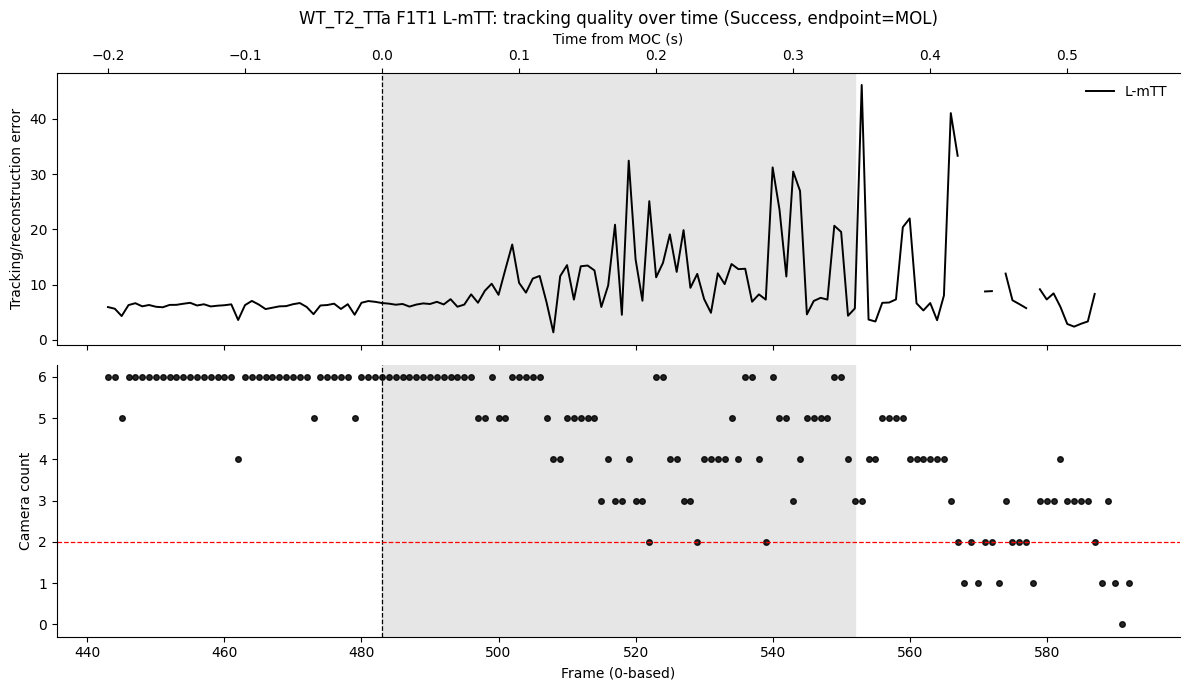

In [13]:
single_trial_qc_prefix = qc_out / f"single_trial_F{FLY_NUMBER}T{TRIAL_NUMBER}_{SINGLE_TRIAL_QC_KEYPOINT}_tracking_quality_over_time"

fig, axes, single_trial_qc_df, single_trial_skipped_df = plotter.plot_single_trial_tracking_quality_over_time(
    groups=groups,
    group_name=GROUP_NAME,
    fly_number=FLY_NUMBER,
    trial_number=TRIAL_NUMBER,
    keypoint=SINGLE_TRIAL_QC_KEYPOINT,
    file_name=str(single_trial_qc_prefix),
    **qc_kwargs,
)

display(single_trial_qc_df.head())
display(single_trial_skipped_df.head())